# NERVE Dataset Exploration

This notebook has two parts: **Part A** uses only the bundled **session registry** (no downloads). **Part B** scans **`config.get_data_root()`** plus any extra data roots for sessions you already extracted (including inside `train/`, `val/`, `test/` subdirectories) and digs into local `annotations.json` and depth thumbnails.


## Part A: Registry-Based Overview


In [2]:
from nerve import registry, config
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

sessions = registry.all_sessions()
DATA_ROOT = Path(config.get_data_root())
n_meta = sum(1 for s in sessions if s.duration_seconds > 0)
print(f"Registered sessions: {len(sessions)}")
print(f"With enriched metadata (duration, sensors, annotations): {n_meta}")
print(f"Data root: {DATA_ROOT}")
if n_meta < len(sessions):
    print(f"\nTip: run  nerve enrich  after downloading more sessions to populate the metadata cache.")


Registered sessions: 116
With enriched metadata (duration, sensors, annotations): 116
Data root: /gpfs/home5/omansour/.nerve/data


In [3]:
enriched = [s for s in sessions if s.duration_seconds > 0]
total_dur = sum(s.duration_seconds for s in enriched)
total_gb = sum(s.size_gb for s in sessions)
print(f"Total archive size (all {len(sessions)} sessions): {total_gb:.2f} GB")
print(f"Total recording duration (enriched {len(enriched)} sessions): {total_dur:.1f} s  ({total_dur/60:.1f} min)")
print(f"Unique persons detected: {sum(s.aggregate.get('unique_persons_detected', 0) for s in enriched)}")
print(f"Total annotations (all POVs): {sum(s.aggregate.get('total_annotations_all_povs', 0) for s in enriched):,}")


Total archive size (all 116 sessions): 459.47 GB
Total recording duration (enriched 116 sessions): 15401.9 s  (256.7 min)
Unique persons detected: 1398
Total annotations (all POVs): 23,463,525


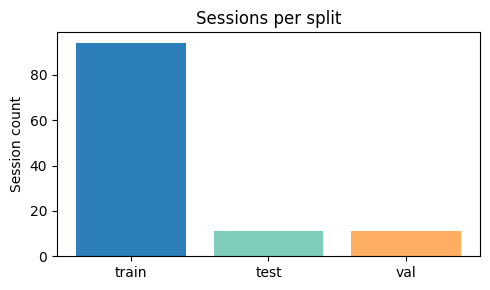

In [4]:
splits = {}
for s in sessions:
    splits[s.split] = splits.get(s.split, 0) + 1

fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(list(splits.keys()), list(splits.values()),
       color=["#2c7fb8", "#7fcdbb", "#fdae61"][:len(splits)])
ax.set_ylabel("Session count")
ax.set_title("Sessions per split")
plt.tight_layout()
plt.show()


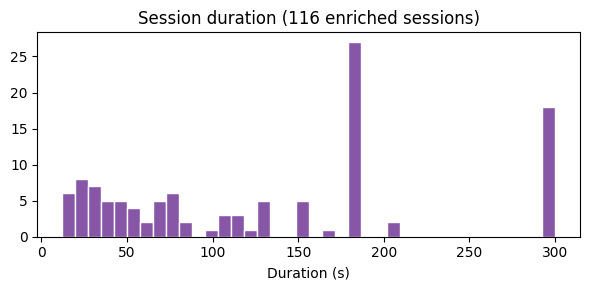

In [5]:
durs = [s.duration_seconds for s in sessions if s.duration_seconds > 0]
fig, ax = plt.subplots(figsize=(6, 3))
if durs:
    ax.hist(durs, bins=min(40, max(5, len(durs) // 3)), color="#8856a7", edgecolor="white")
    ax.set_xlabel("Duration (s)")
    ax.set_title(f"Session duration ({len(durs)} enriched sessions)")
else:
    ax.text(0.5, 0.5, "No enriched sessions -- run  nerve enrich  first",
            ha="center", va="center")
    ax.set_axis_off()
plt.tight_layout()
plt.show()


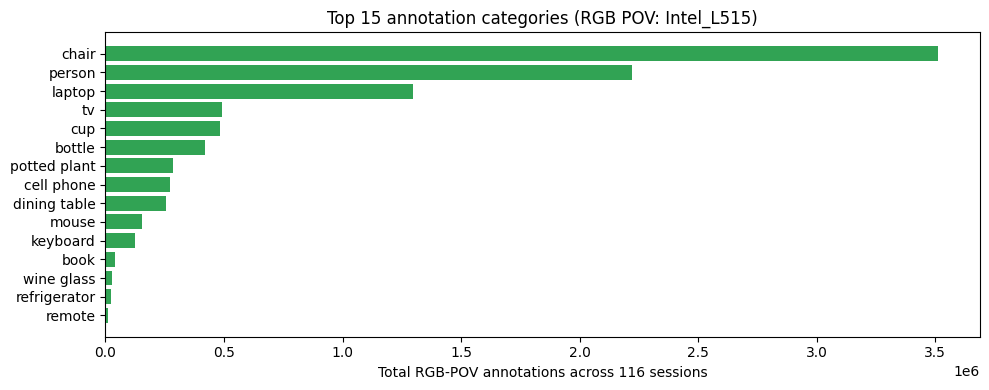

In [6]:
from collections import Counter

RGB_SENSOR = "Intel_L515"

cat_counts = Counter()
sessions_with_rgb = 0
for s in sessions:
    rgb_ann = (s.annotations or {}).get(RGB_SENSOR)
    if not rgb_ann:
        continue
    sessions_with_rgb += 1
    per_cat = rgb_ann.get("annotations_per_category") or rgb_ann.get("categories") or {}
    for cname, count in per_cat.items():
        cat_counts[cname] += count if isinstance(count, (int, float)) else 1

if not cat_counts:
    print(f"No per-category annotation data found for the RGB POV ({RGB_SENSOR}).")
    print("Run  nerve enrich  after downloading sessions to populate.")
else:
    top = cat_counts.most_common(15)
    labels, vals = zip(*top)
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.barh(range(len(labels)), vals, color="#31a354")
    ax.set_yticks(range(len(labels)), labels)
    ax.set_xlabel(f"Total RGB-POV annotations across {sessions_with_rgb} sessions")
    ax.set_title(f"Top 15 annotation categories (RGB POV: {RGB_SENSOR})")
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()


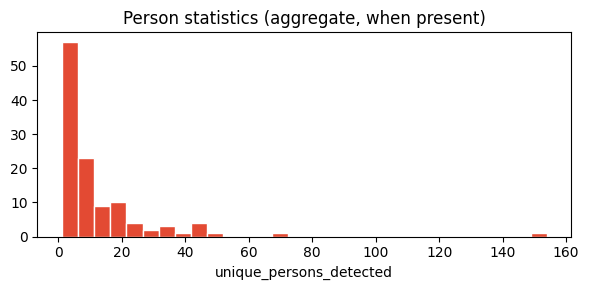

In [8]:
persons = [float(s.aggregate.get("unique_persons_detected", 0)) for s in sessions]
persons = [p for p in persons if p > 0]
fig, ax = plt.subplots(figsize=(6, 3))
if persons:
    ax.hist(persons, bins=min(30, max(5, len(persons))), color="#e34a33", edgecolor="white")
    ax.set_xlabel("unique_persons_detected")
    ax.set_title("Person statistics (aggregate, when present)")
else:
    ax.text(0.5, 0.5, "No unique_persons_detected in registry", ha="center", va="center")
    ax.set_axis_off()
plt.tight_layout()
plt.show()


/scratch-local/74681/ipykernel_1686399/2606786013.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels)


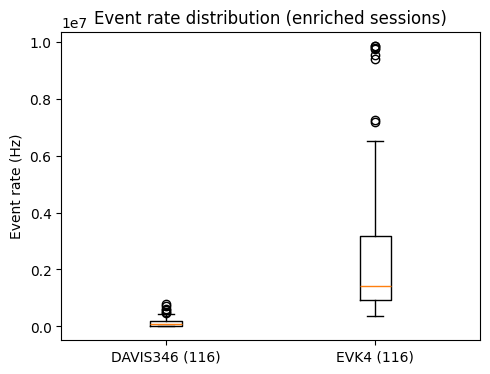

In [9]:
def rate_for(s, key):
    d = s.sensor_details or {}
    block = d.get(key) or {}
    obs = block.get("observation", {})
    for cand in ("event_rate_hz", "mean_event_rate_hz", "mean_event_rate"):
        if cand in obs:
            return float(obs[cand])
        if cand in block:
            return float(block[cand])
    return None

r_d = [rate_for(s, "DAVIS346") for s in sessions]
r_e = [rate_for(s, "EVK4") for s in sessions]
r_d = [x for x in r_d if x is not None]
r_e = [x for x in r_e if x is not None]

fig, ax = plt.subplots(figsize=(5, 4))
if r_d or r_e:
    data, labels = [], []
    if r_d:
        data.append(r_d)
        labels.append(f"DAVIS346 ({len(r_d)})")
    if r_e:
        data.append(r_e)
        labels.append(f"EVK4 ({len(r_e)})")
    ax.boxplot(data, labels=labels)
    ax.set_ylabel("Event rate (Hz)")
    ax.set_title("Event rate distribution (enriched sessions)")
else:
    ax.text(0.5, 0.5, "No event rates in metadata -- run  nerve enrich",
            ha="center", va="center")
    ax.set_axis_off()
plt.tight_layout()
plt.show()


In [10]:
sorted_sessions = sorted(sessions, key=lambda s: s.size_bytes)
max_gb = 50.0
budget = max_gb * 1e9
chosen, total = [], 0.0
for s in sorted_sessions:
    if total + s.size_bytes <= budget:
        chosen.append(s)
        total += s.size_bytes
print(f"Greedy pack by smallest archive first: {len(chosen)} sessions within {max_gb} GB")
print(f"Total size (GB): {total/1e9:.2f}")
print("First 10:", [c.name for c in chosen[:10]])


Greedy pack by smallest archive first: 40 sessions within 50.0 GB
Total size (GB): 48.72
First 10: ['2023-10-26_15-37-59', '2023-12-05_12-16-03', '2023-12-05_12-15-41', '2023-12-05_12-14-02', '2023-12-06_15-23-09', '2023-10-26_15-55-08', '2023-12-05_12-11-22', '2023-12-04_12-16-18', '2023-10-26_16-13-03', '2023-12-05_12-05-24']


## Part B: Deep Exploration (Local Session Files)


![BBOX diagonal distribution](figures/bbox_diagonal_distribution_rgb.png) ![BBOX center distribution](figures/bbox_center_heatmap_rgb_smoothed.png)

![Distance distribution](figures/distance_distribution_rgb.png)
![Human Frame distribution](figures/humans_per_frame_distribution_rgb.png)
